In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CIDER import response_from_all_injections_and_CO2,AOD_from_injection, pattern_from_all_injections_and_CO2
from Toolbox import global_mean, lat_band_mean, stack_and_zoh_injections
import CIDER

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import os

import xesmf as xe
import pandas as pd

plt.rcParams.update({'font.size': 13})

## Get CIDER scenario for injections linearly incr. to 8 MT/yr in 2100

In [11]:
run load_all_other_variables.py # make sure model = 'UKESM'

In [12]:
print(model) # make sure model = 'UKESM'

UKESM


In [13]:
# linear increase to 8 Tg / yr

end_yr = 2100
start_yr = 2035
yrs_per_cycle = 1

total_years = end_yr - start_yr
years_represented_by_array_element = yrs_per_cycle # 1/ ArrayLength 
n_yrs = end_yr - start_yr
if n_yrs % yrs_per_cycle != 0:
    raise ValueError(f"Number of years ({n_yrs}) is not a whole number of cycles ({yrs_per_cycle}-year).")

n_cycles = n_yrs / yrs_per_cycle

rampup_max = 8  # max inj in Tg / yr
rampup_period = total_years # in yrs 

rampup_cycles = rampup_period / yrs_per_cycle
rampup_step = rampup_max / rampup_cycles

inj_rampup = np.arange(0,rampup_max, rampup_step)
inj_constant = np.full(int(n_cycles - len(inj_rampup))+1, rampup_max)

inj = np.concat([inj_rampup[1:], inj_constant])

inj_zeros = np.zeros(int(n_yrs/yrs_per_cycle))

# these are Tg/yr, each number in array corresponding to number of years defined above

In [14]:
# creating coordinates 

lon = np.linspace(0, 360, 288, endpoint=False)
lat = np.linspace(-90, 90, 192)
years_2035_2100 = np.arange(2035,2100,1)
years_1855_2095 = np.arange(1855,2096,1)
years_2035_2095 = np.arange(2035,2096,1)

lat2d, lon2d = np.meshgrid(lat, lon)

lat2d_NH = lat2d[:, 96:] 
lon2d_NH = lon2d[:, 96:] 

lat2d_SH = lat2d[:, :96] 
lon2d_SH = lon2d[:, :96] 

weights = np.cos(np.deg2rad(lat))
weights_NH = weights[96:] 
weights_SH = weights[:96] 

In [15]:
i_60N = np.array(inj)
i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S = inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros 

i_scen1 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen1 = np.concatenate((i_scen1,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

scen1_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen1_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all)

# creating NH, SH, IHTD 

SAI_pattern_reshaped = scen1_pattern.reshape(288, 192, total_years, 12) # split inot years and months
SAI_pat = SAI_pattern_reshaped.mean(axis=-1)   # avg over years

SAI_NH_pat = SAI_pat[:, 96: , :]  # isolate NH   # cause lats are from -90 to 90
SAI_SH_pat = SAI_pat[:, :96 , :]  # isolate SH

SAI_NH_avglat = np.average(SAI_NH_pat, weights = weights_NH, axis = 1)
SAI_NH = np.average(SAI_NH_avglat, axis = 0)

SAI_SH_avglat = np.average(SAI_SH_pat, weights = weights_SH, axis = 1)
SAI_SH = np.average(SAI_SH_avglat, axis = 0)

SAI_ITD = SAI_NH - SAI_SH


In [16]:
# no injection scenarios

no_injection = np.zeros((total_years*12, 7))
no_injection_and_CO2 = np.concatenate((no_injection,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

SSP245_T_response = response_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all)
SSP245_T_pattern = pattern_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all, all_T_patterns_scaled)

# creating NH, SH, IHTD 

s245_pattern_reshaped = SSP245_T_pattern.reshape(288, 192, total_years, 12) # split inot years and months
s245_pat = s245_pattern_reshaped.mean(axis=-1)   # avg over years

s245_NH_pat = s245_pat[:, 96: , :]  # isolate NH   # cause lats are from -90 to 90
s245_SH_pat = s245_pat[:, :96 , :]  # isolate SH

s245_NH_avglat = np.average(s245_NH_pat, weights = weights_NH, axis = 1)
s245_NH = np.average(s245_NH_avglat, axis = 0)

s245_SH_avglat = np.average(s245_SH_pat, weights = weights_SH, axis = 1)
s245_SH = np.average(s245_SH_avglat, axis = 0)

s245_ITD = s245_NH - s245_SH


## Plot

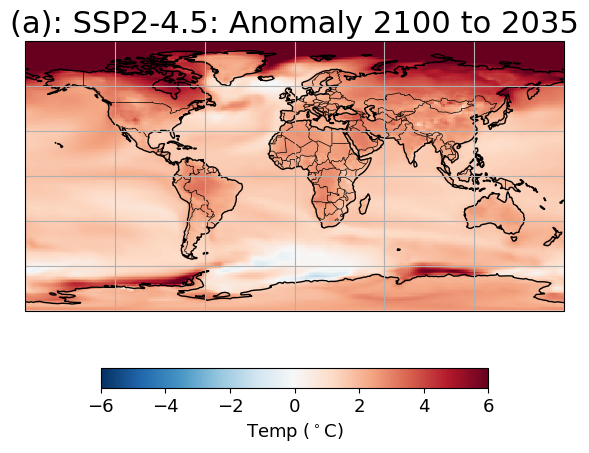

np.float64(6.099)

In [17]:
# CIDER anomaly: scen

year_index = 64

cmap = 'RdBu_r'
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)  # Adjust vmin/vmax to fit your data range
units = '($^\circ$C)'


data_to_plot = s245_pat[:,:,year_index]

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.gridlines()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_global()

img = ax.pcolormesh(lon2d, lat2d, data_to_plot, cmap=cmap, norm = norm)

plt.colorbar(img, orientation='horizontal', shrink = 0.5, label=f'Temp {units}')

#title = f"{model2use}1: {scen_names[scenario]}: Anomaly {2035 + year_index +1} to 2035"
title = f"(a): SSP2-4.5: Anomaly {2035 + year_index +1} to 2035"
plt.title(title, fontsize = 22)
plt.savefig(f'PD_figures/{title}.jpg', dpi=350)

plt.show()

arctic_diff = data_to_plot[:, 158:]
arctic_diff = round(arctic_diff.mean(),3)
arctic_diff

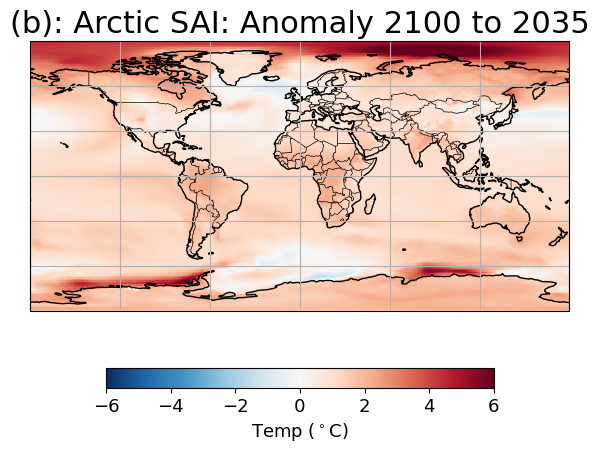

np.float64(2.952)

In [18]:
# CIDER anomaly: scen

cmap = 'RdBu_r'
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)  # Adjust vmin/vmax to fit your data range
units = '($^\circ$C)'

data_to_plot = SAI_pat[:,:,year_index]


fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.gridlines()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_global()

img = ax.pcolormesh(lon2d, lat2d, data_to_plot, cmap=cmap, norm = norm)

plt.colorbar(img, orientation='horizontal', shrink = 0.5, label=f'Temp {units}')

title = f"(b): Arctic SAI: Anomaly {2035 + year_index +1} to 2035"
plt.title(title, fontsize = 22)
plt.savefig(f'PD_figures/{title}.jpg', dpi=350)

plt.show()

arctic_diff = data_to_plot[:, 158:]
arctic_diff = round(arctic_diff.mean(),3)
arctic_diff

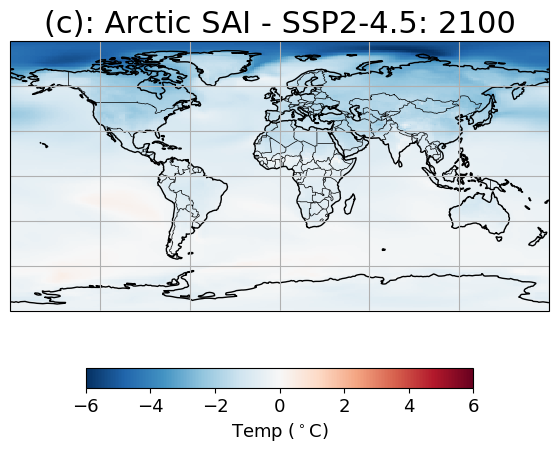

In [19]:
# CIDER anomaly: scens diff

cmap = 'RdBu_r'
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)  # Adjust vmin/vmax to fit your data range
units = '($^\circ$C)'

data_to_plot_1 = s245_pat[:,:,year_index]
data_to_plot_2 = SAI_pat[:,:,year_index]
data_to_plot = data_to_plot_2 - data_to_plot_1

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.gridlines()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_global()

img = ax.pcolormesh(lon2d, lat2d, data_to_plot, cmap=cmap, norm = norm)

plt.colorbar(img, orientation='horizontal', shrink = 0.5, label=f'Temp {units}')

#title = f"{model2use}1: {scen_names[scenario1]} - {scen_names[scenario2]} : {2035 + year_index +1}"
title = f"(c): Arctic SAI - SSP2-4.5: {2035 + year_index +1}"

plt.title(title, fontsize = 22)
plt.savefig(f'PD_figures/{title} .jpg', dpi=350)

plt.show()